# Mathematical Engineering - Financial Engineering, FY 2025-2026
# Risk Management - Exercise 5: Extended Vasiceck model Monte Carlo simulation for CCR estimation

#### Import the libraries and functions needed created in previous labs

In [1]:
# Importing the libraries
import os
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from utilities.date_functions import (
    business_date_offset,
    date_series,
    year_frac_act_x,
    year_frac_30e_360
)

from utilities.ex0_utilities import (
    bootstrap,
    from_discount_factors_to_zero_rates,
    get_discount_factor_by_zero_rates_linear_interp)

from utilities.ex1_utilities import (
    swap_par_rate,
    SwapType
)

from utilities.ex5_utilities import (
    simulate_ou_process,
    affine_trick,
    update_collateral
)

#### Bootstrap 

In [2]:
'''
# Import here the market data and run your bootstrap function

data_path = Path("data")

df_dt = pd.read_csv(data_path / "dt.csv")
settlement_date = pd.to_datetime(df_dt.loc[df_dt['Market'] == 'Settlement', 'TARGET'].values[0])

df_depos = pd.read_csv(data_path / "depos.csv")
df_futures = pd.read_csv(data_path / "futures.csv")
df_swaps = pd.read_csv(data_path / "swaps.csv")

# Bootstrap
discount_factors, zero_rates = bootstrap(settlement_date, df_depos, df_futures, df_swaps)
'''

'\n# Import here the market data and run your bootstrap function\n\ndata_path = Path("data")\n\ndf_dt = pd.read_csv(data_path / "dt.csv")\nsettlement_date = pd.to_datetime(df_dt.loc[df_dt[\'Market\'] == \'Settlement\', \'TARGET\'].values[0])\n\ndf_depos = pd.read_csv(data_path / "depos.csv")\ndf_futures = pd.read_csv(data_path / "futures.csv")\ndf_swaps = pd.read_csv(data_path / "swaps.csv")\n\n# Bootstrap\ndiscount_factors, zero_rates = bootstrap(settlement_date, df_depos, df_futures, df_swaps)\n'

In [3]:
today = pd.Timestamp("2008-02-15") 
settlement_date = business_date_offset(today, day_offset=2)

# Load Mkt Data as readable by the bootstrap function
#/// Depos
depo_converter = lambda x: float(x)/100.0  
df_depos = pd.read_csv('data/depos.csv', 
                   index_col ='Depos',
                   usecols = ['Depos','ASK','BID'], 
                   converters={'Depos':pd.to_datetime,'BID':depo_converter,'ASK':depo_converter})

#/// Futures
future_converter = lambda x: float(x)
futures = pd.read_csv('data/futures.csv',
                      index_col ='Futures',
                      usecols = ['Futures','ASK','BID'],
                      converters={'Futures':pd.to_datetime,'BID':future_converter,'ASK':future_converter})
expiry = pd.read_csv('data/expiry.csv',
                     index_col = 'Futures',
                     usecols =['Futures', 'Settle', 'Expiry'], 
                     converters = {'Futures':pd.to_datetime, 'Settle':pd.to_datetime, 'Expiry':pd.to_datetime})
df_futures = futures.join(expiry)

#/// Swaps
swap_converter = lambda x: float(x)
df_swaps = pd.read_csv('data/swaps.csv',
                    index_col = 'Swaps',
                    usecols = ['Swaps','BID','ASK'],
                    converters={'Swaps':pd.to_datetime,'BID':swap_converter,'ASK':swap_converter})

# Bootstrap the discount curve
discount_factors, zero_rates = bootstrap(today,df_depos, df_futures, df_swaps)

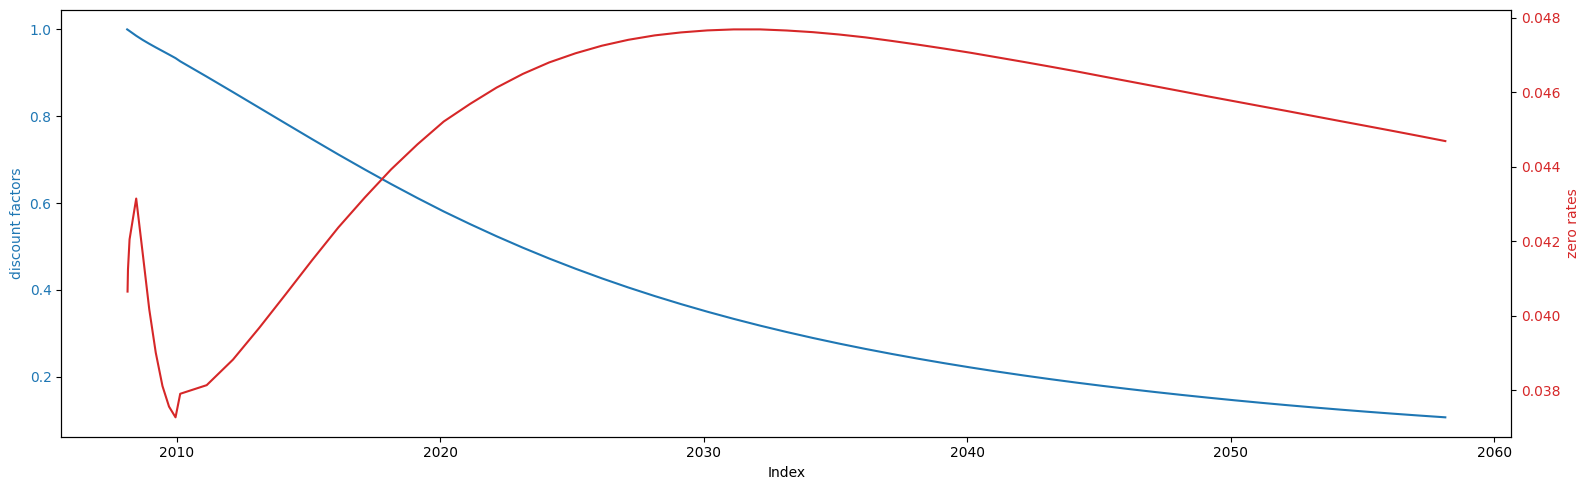

In [4]:
fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(discount_factors.index, discount_factors.values, color='tab:blue')
ax1.set_ylabel('discount factors', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(zero_rates.index, zero_rates.values, color='tab:red')
ax2.set_ylabel('zero rates', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_xlabel('Index')
plt.tight_layout()

plt.show()


#### MonteCarlo grid set up

In [5]:
# Monte Carlo Simulations parameters, grids and outputs to store

# params
simulations_num = 250_000   ######################## ERROR 250 000
years_to_simulate = 10

# last point on the simulation grid
simulations_expiry = business_date_offset(settlement_date, year_offset=years_to_simulate)  ######### ERROR

# 40 simulation dates (t_0 non a simulation date)
total_point = 40
point_per_year = total_point//years_to_simulate
simulation_grid = date_series(settlement_date, simulations_expiry, point_per_year)[1:]
simulation_grid = pd.DatetimeIndex(simulation_grid)

# output to compute
expected_positive_exposure = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base", "break", "no netting", "netting", "collateral"])

alpha = 0.95
potential_future_exposure = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base", "break", "no netting", "netting", "collateral"]
)

#### Set up of the base contract

In [6]:
####### 10 y payer swap #######

# Parameters for the 10y payer swap
notional = 100_000_000
swap_type = SwapType.PAYER
maturity = 10
fixed_freq = 1 # annual


expiry = business_date_offset(settlement_date, year_offset=maturity)
fixed_leg_payment_dates = date_series(settlement_date, expiry, fixed_freq)

# assume swap traded at par
swap_rate = swap_par_rate( fixed_leg_payment_dates, discount_factors ) ### controlla come è definita la funzione che importiamo da ex1 utilities

yf_fixed = [year_frac_30e_360(fixed_leg_payment_dates[i-1], fixed_leg_payment_dates[i]) for i in range(1, len(fixed_leg_payment_dates))]


'''
# fixed leg cash flows
irs_cash_flows = pd.Series(
    data=[
        swap_rate
        for count in range(1, len(fixed_leg_payment_dates))],
                
    index=fixed_leg_payment_dates[1:])


# fixed leg cash flows extended on simulation grid
# verify that all the payments fall on a t already included in the simulation grid
irs_cash_flows_extended = (
    irs_cash_flows
    .reindex(simulation_grid, fill_value=0.0)
)
    
'''


irs_cash_flows = pd.Series(
    data=np.array(yf_fixed) * swap_rate,
    index=fixed_leg_payment_dates[1:]
)

irs_cash_flows_extended = irs_cash_flows.reindex(simulation_grid, fill_value=0.0)



#### Set up of the alternative scenarios 

In [7]:
# a) mandatory break clause
# Set up of the break date
break_year = 3
break_month = 6


break_expiry = business_date_offset(settlement_date, year_offset = break_year, month_offset = break_month )


# b) 5 y payer swap
# Parameters for the 5y receiver swap
# swap 2 has fixed leg quarterly, float leg quarterly (euribor 3m), same yf conventions of base swap
notional_2 = 150_000_000
swap_type_2 = SwapType.RECEIVER
maturity_2 = 5
fixed_freq_2 = 4 


expiry_2 = business_date_offset(settlement_date, year_offset = maturity_2 )
fixed_leg_payment_dates_2 = date_series(settlement_date, expiry_2, fixed_freq_2)

# assume swap traded at par
swap_rate_2 = swap_par_rate( fixed_leg_payment_dates_2, discount_factors ) ### controlla come è definita la funzione che importiamo da ex1 utilities

'''
# fixed leg cash flows
irs_cash_flows_2 = pd.Series(
    data=[
        swap_rate_2
        for count in range(1, len(fixed_leg_payment_dates_2))],
                
    index=fixed_leg_payment_dates_2[1:])


# fixed leg cash flows extended on simulation grid
irs_cash_flows_extended_2 = (
    irs_cash_flows_2
    .reindex(simulation_grid, fill_value=0.0)
)

'''

yf_fixed_2 = [year_frac_30e_360(fixed_leg_payment_dates_2[i-1], fixed_leg_payment_dates_2[i]) for i in range(1, len(fixed_leg_payment_dates_2))]

irs_cash_flows_2 = pd.Series(
    data=np.array(yf_fixed_2) * swap_rate_2,
    index=fixed_leg_payment_dates_2[1:]
)

irs_cash_flows_extended_2 = irs_cash_flows_2.reindex(simulation_grid, fill_value=0.0)


# c) CSA agreement
# No IA, no rounding, no haircut, no delay in the posting of the collateral (i.e. margin call done at t -> new collateral posted at t)
# CSA parameters for party B (Polimi Bank)


# we select THR_B = +inf such that Polimi Bank is never required to post collateral
# since in this way is always true that min(MtM + THR_B,0) = 0 
THR_B = np.inf
MTA_B = 0      # given, choose correctly the other parameters
Cap_B = np.inf # given, choose correctly the other parameters

# we select THR_C = 0 such that the counterparty fully covers its exposure
# since in this way is always true that max(MtM - THR_C, 0) = MtM (for MtM >= 0).
# Moreover, we select Cap_C = +inf to ensure there is no upper limit to the collateral C must post
THR_C = 0 
MTA_C = 0      # given, choose correctly the other parameters
Cap_C = np.inf

In [8]:
print("--- SANITY CHECKS: SWAP RATES ---")
print(f"10Y Payer Swap Rate (Base): {swap_rate:.4%}")
print(f"5Y Receiver Swap Rate (Netting): {swap_rate_2:.4%}")

--- SANITY CHECKS: SWAP RATES ---
10Y Payer Swap Rate (Base): 4.4338%
5Y Receiver Swap Rate (Netting): 3.9812%


#### x_t OU Process simulations

In [9]:
# OU process parameters

mean_reversion = 0.0205
sigma = 0.0094

In [10]:
np.random.seed(78)

x_paths = simulate_ou_process(simulation_grid,
                              settlement_date, 
                              mean_reversion, 
                              sigma, 
                              simulations_num,
                              x0=0)

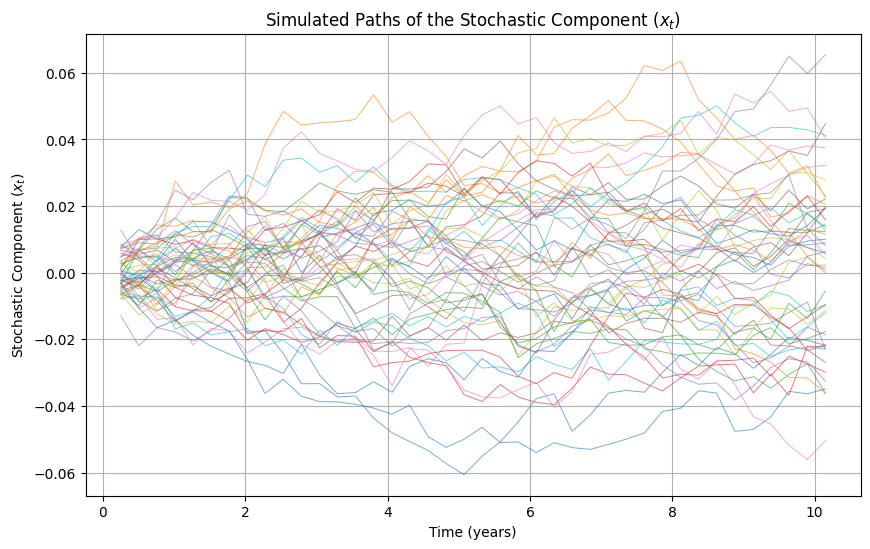

In [11]:
time_axis = [
    year_frac_act_x(settlement_date, d, 360)
    for d in simulation_grid
]

plt.figure(figsize=(10,6))

for k in range(50):   # only 50 paths for readability
    plt.plot(time_axis, x_paths[k,:], lw=0.7, alpha=0.6)

plt.title("Simulated Paths of the Stochastic Component ($x_t$)")
plt.xlabel("Time (years)")
plt.ylabel("Stochastic Component ($x_t$)")
plt.grid(True)
plt.show()

#### From OU to discount factors and MtM and exposures

In [12]:
# Inizialization of zero rates
zero_rates = (
    zero_rates.reindex(zero_rates.index.union([simulation_grid[0]]))
    .sort_index()
    .interpolate(method="index")
)

# Inizialization collateral
collateral_posted = np.zeros(simulations_num)
risk_free_rate = np.full(simulations_num, zero_rates.loc[simulation_grid[0]])
last_collateral_posting_date = settlement_date


for i, sim_date in enumerate(simulation_grid[0:]):

    if i == 0:
        prev_date = settlement_date
    else:
        prev_date = simulation_grid[i-1]

    dt = year_frac_act_x(prev_date, sim_date, 360)

    # Market simulation at time sim_date
    x_t = x_paths[:, i]
    
    # A and C changes at each sim_date, but are common across simulations
    A, C = affine_trick( sim_date, simulation_grid, mean_reversion, sigma, discount_factors )

    # discounts factor (sim_date,t_j) in each scenario, for each t_j in the simulation_grid, use the affine formula
    discount_factors_hw = A.values * np.exp(-np.outer(x_t, C.values))
    

    # discounted cashflows 
    if sim_date < expiry:

        floating_leg = 1 - discount_factors_hw[ : , -1 ]

        future_mask = np.array([d > sim_date for d in simulation_grid])

        fixed_leg = np.sum( discount_factors_hw[:, future_mask] * irs_cash_flows_extended.values[future_mask], axis=1 )

        #fixed_leg = np.sum( discount_factors_hw[ : , i+1: ] * irs_cash_flows_extended.values[ i+1: ], axis=1 )

        discounted_cash_flows = floating_leg - fixed_leg

    else:
        discounted_cash_flows = np.zeros(simulations_num)


    # mark-to-future (MtM_t)
    MtF = notional * discounted_cash_flows 

    # remunerate the collateral posted
    collateral_posted *= np.exp(risk_free_rate * year_frac_act_x(prev_date, sim_date, 360)) ### possiamo sostituire questa year frac con dt

    if (sim_date - last_collateral_posting_date).days >= 360:
        last_collateral_posting_date = sim_date
        collateral_posted = update_collateral(MtF,collateral_posted,THR_B,THR_C,MTA_B,MTA_C,Cap_B,Cap_C)
    
    MtF_coll = MtF - collateral_posted



    # SCENARIO a

    if sim_date >= break_expiry:
        MtF_break = np.zeros(simulations_num)
    else:
        MtF_break = MtF
    
    # SCENARIO b
    if sim_date < expiry_2:
        idx = simulation_grid.get_loc(expiry_2)
        floating_leg_2 = 1 - discount_factors_hw[:,idx]

        future_mask = np.array([d > sim_date for d in simulation_grid])

        fixed_leg_2 = np.sum( discount_factors_hw[ :, future_mask ] * irs_cash_flows_extended_2.values[ future_mask ], axis=1 )
        
        discount_factors_hw_2 = fixed_leg_2 - floating_leg_2
        
        MtM_2 = notional_2 * discount_factors_hw_2

    else:
        MtM_2 = np.zeros(simulations_num)


    # Positive exposure
    # Base scenario
    MtF_pos = np.maximum(MtF, 0)
    # Scenario a
    MtF_pos_break = np.maximum(MtF_break, 0)
    # Scenario b
    MtF_pos_swap2 = np.maximum(MtM_2, 0)
    MtF_pos_no_netting = MtF_pos + MtF_pos_swap2
    MtF_pos_netting = np.maximum(MtF + MtM_2, 0)
    # Scenario c
    MtF_pos_coll = np.maximum(MtF_coll, 0) 


    # Expected exposure
    expected_positive_exposure.loc[sim_date, "base"] = np.mean(MtF_pos)
    expected_positive_exposure.loc[sim_date, "break"] = np.mean(MtF_pos_break)
    expected_positive_exposure.loc[sim_date, "no netting"] = np.mean(MtF_pos_no_netting)
    expected_positive_exposure.loc[sim_date, "netting"] = np.mean(MtF_pos_netting)
    expected_positive_exposure.loc[sim_date, "collateral"] = np.mean(MtF_pos_coll)
    

    # Potential future exposure
    potential_future_exposure.loc[sim_date, "base"] = np.quantile(MtF_pos, alpha)
    potential_future_exposure.loc[sim_date, "break"] = np.quantile(MtF_pos_break, alpha)
    potential_future_exposure.loc[sim_date, "no netting"] = np.quantile(MtF_pos_no_netting, alpha)
    potential_future_exposure.loc[sim_date, "netting"] = np.quantile(MtF_pos_netting, alpha)
    potential_future_exposure.loc[sim_date, "collateral"] = np.quantile(MtF_pos_coll, alpha)


    '''
    # Risk-free rate update
    if i < len(simulation_grid) - 1:
        
        idx = A.index.get_loc(sim_date)

        future_dfs = [discount_factors_hw[:, j] for j in range(idx+1, len(simulation_grid))]

        year_fracs = [year_frac_act_x(sim_date, d, 360) for d in simulation_grid[idx+1:]]
        
        # use the shortest maturity zero rate
        risk_free_rate = -np.log(future_dfs[0]) / year_fracs[0]
    '''

    if i < len(simulation_grid) - 1:
        idx = A.index.get_loc(sim_date)
        future_df_1_period = discount_factors_hw[:, idx + 1]
        year_frac_1_period = year_frac_act_x(sim_date, simulation_grid[idx + 1], 360)
        risk_free_rate = -np.log(future_df_1_period) / year_frac_1_period




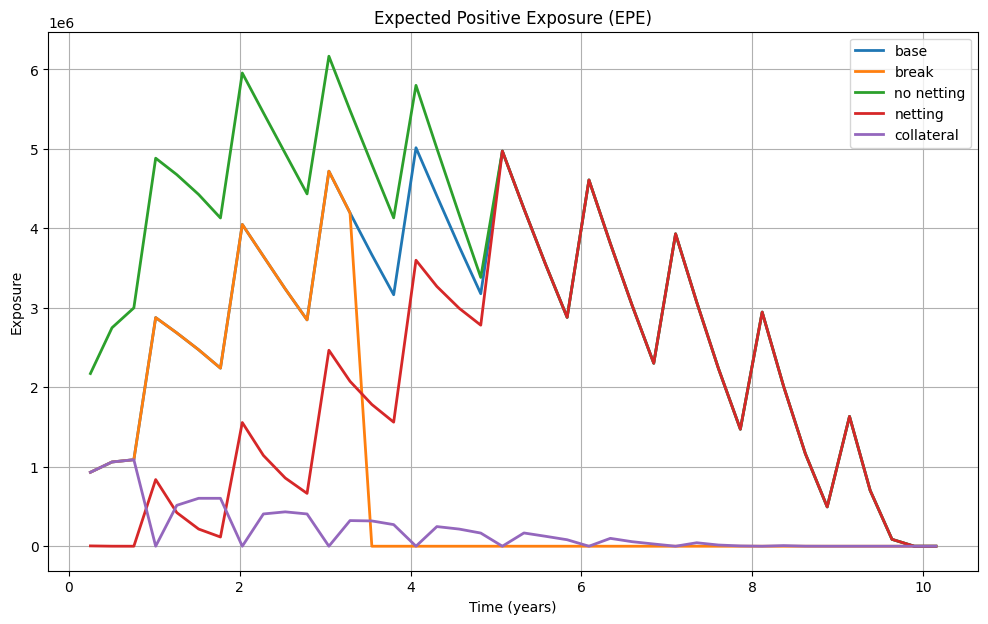

In [13]:
plt.figure(figsize=(12,7))

for col in expected_positive_exposure.columns:
    plt.plot(
        time_axis,
        expected_positive_exposure[col],
        label=col,
        lw=2
    )

plt.title("Expected Positive Exposure (EPE)")
plt.xlabel("Time (years)")
plt.ylabel("Exposure")
plt.legend()
plt.grid(True)
plt.show()

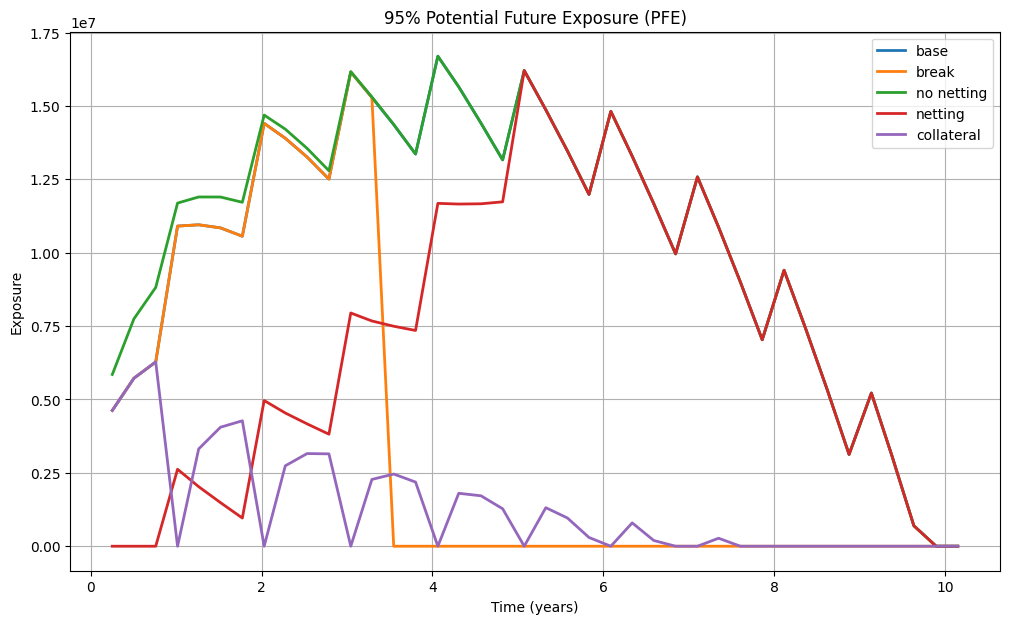

In [14]:
plt.figure(figsize=(12,7))

for col in potential_future_exposure.columns:
    plt.plot(
        time_axis,
        potential_future_exposure[col],
        label=col,
        lw=2
    )

plt.title(f"{int(alpha*100)}% Potential Future Exposure (PFE)")
plt.xlabel("Time (years)")
plt.ylabel("Exposure")
plt.legend()
plt.grid(True)
plt.show()

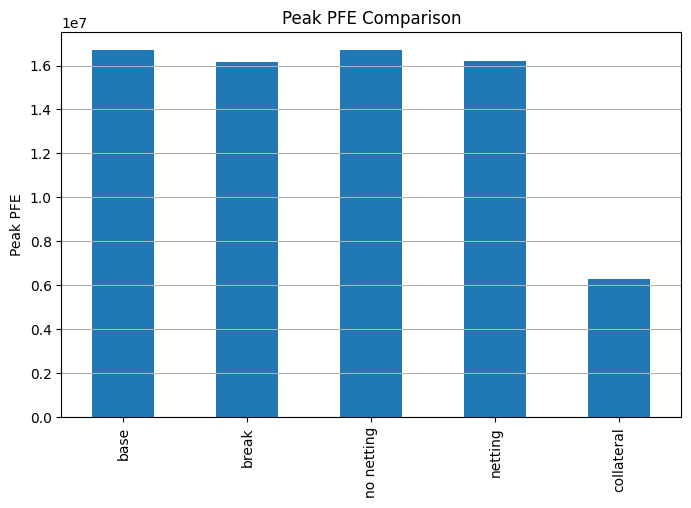

In [15]:
peak_pfe = potential_future_exposure.max()

plt.figure(figsize=(8,5))

peak_pfe.plot(kind='bar')

plt.title("Peak PFE Comparison")
plt.ylabel("Peak PFE")
plt.grid(True, axis='y')
plt.show()

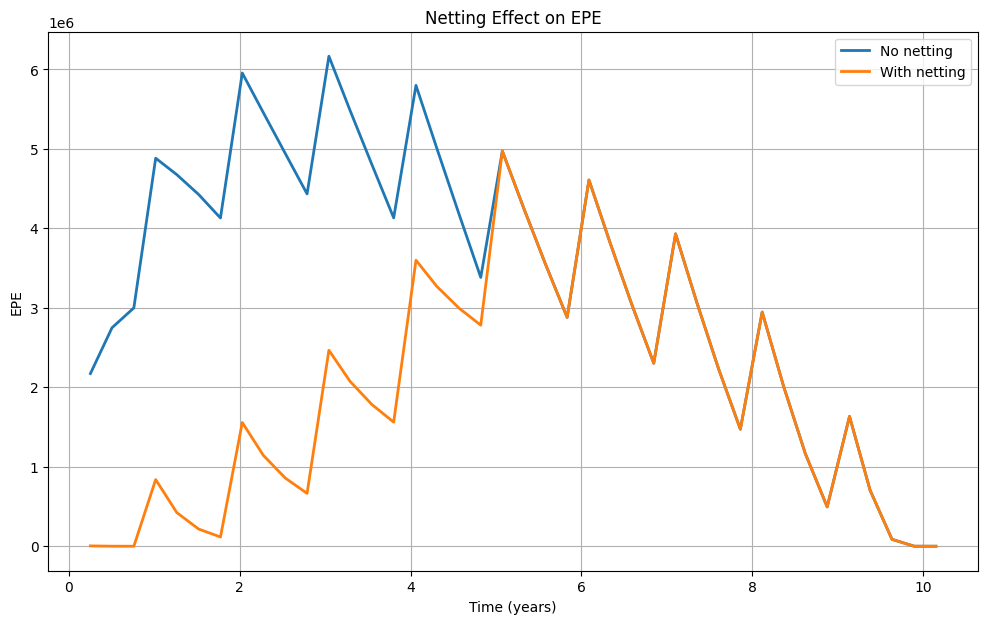

In [16]:
plt.figure(figsize=(12,7))

plt.plot(
    time_axis,
    expected_positive_exposure["no netting"],
    label="No netting",
    lw=2
)

plt.plot(
    time_axis,
    expected_positive_exposure["netting"],
    label="With netting",
    lw=2
)

plt.title("Netting Effect on EPE")
plt.xlabel("Time (years)")
plt.ylabel("EPE")
plt.legend()
plt.grid(True)
plt.show()

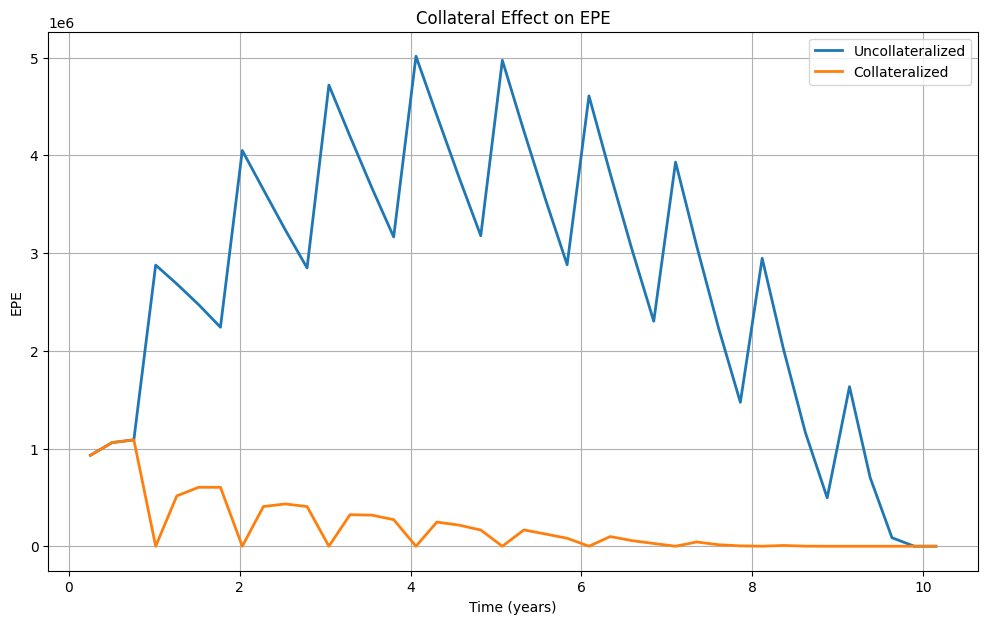

In [17]:
plt.figure(figsize=(12,7))

plt.plot(
    time_axis,
    expected_positive_exposure["base"],
    label="Uncollateralized",
    lw=2
)

plt.plot(
    time_axis,
    expected_positive_exposure["collateral"],
    label="Collateralized",
    lw=2
)

plt.title("Collateral Effect on EPE")
plt.xlabel("Time (years)")
plt.ylabel("EPE")
plt.legend()
plt.grid(True)
plt.show()

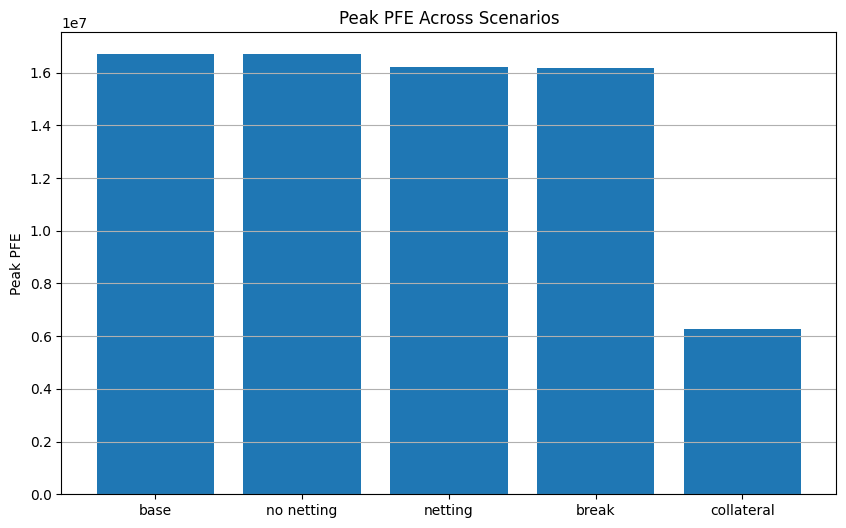

In [18]:
comparison = pd.DataFrame({
    "Scenario": peak_pfe.index,
    "PeakPFE": peak_pfe.values
})

comparison = comparison.sort_values("PeakPFE", ascending=False)

plt.figure(figsize=(10,6))

plt.bar(
    comparison["Scenario"],
    comparison["PeakPFE"]
)

plt.title("Peak PFE Across Scenarios")
plt.ylabel("Peak PFE")
plt.grid(True, axis='y')
plt.show()

#### Peak PFE

In [19]:
# Compute for each scenario the peak-PFE and the t at which it materialize
peak_pfe = pd.DataFrame(data = 0, index=["base", "break", "no netting", "netting", "collateral"], columns = ['t','Peak_PFE'])
peak_pfe['Peak_PFE'] = None
peak_pfe['t']= None

#### PLOT 

<Figure size 1500x500 with 0 Axes>

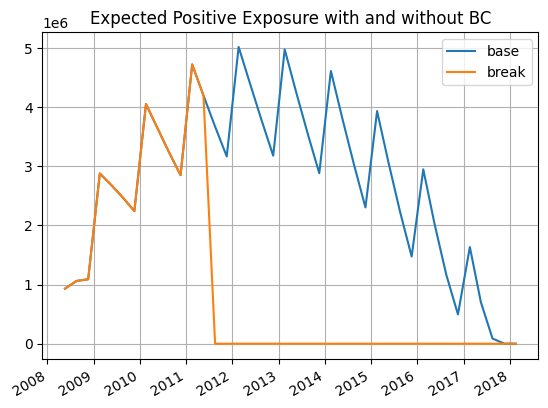

<Figure size 1500x500 with 0 Axes>

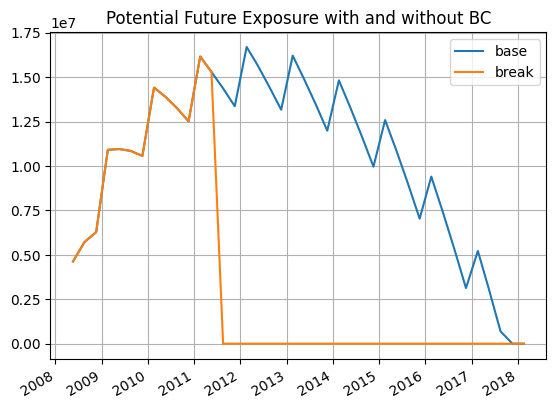

In [20]:
### plot 6 a
plt.figure(figsize=(15, 5))
expected_positive_exposure[['base','break']].plot()
plt.title(f"Expected Positive Exposure with and without BC")
plt.grid()
plt.show()

plt.figure(figsize=(15, 5))
potential_future_exposure[['base','break']].plot()
plt.title(f"Potential Future Exposure with and without BC")
plt.grid()
plt.show()

### plot 6 b

### plot 6 c


#### CVA estimations

In [21]:
# Parameters
hazard_rate = 0.02
lgd = 0.6

In [29]:
# !!! COMPLETE AS APPROPRIATE !!! 
# ---------------------------------------------------------
# Question 7a: Approximate CVA(t_0) Estimation
# ---------------------------------------------------------

# 1. Compute time steps in years from t_0 (settlement_date)
t_values = np.array([year_frac_act_x(settlement_date, d, 360) for d in simulation_grid])
# Insert t_0 = 0.0 at the beginning to represent t_{k-1} for the first interval
t_prev = np.insert(t_values[:-1], 0, 0.0)

# 2. Compute Survival Probabilities and Marginal PDs
# S(t) = exp(-lambda * t)
surv_prob_t = np.exp(-hazard_rate * t_values)
surv_prob_prev = np.exp(-hazard_rate * t_prev)
# PD in interval (t_{k-1}, t_k]
pd_interval = surv_prob_prev - surv_prob_t

# 3. Get Discount Factors B(t_0, t_k)
# Re-using the linear interpolation utility from Ex 0
df_t = np.array([
    get_discount_factor_by_zero_rates_linear_interp(
        settlement_date, d, discount_factors.index, discount_factors.values
    ) for d in simulation_grid
])

# 4. Calculate CVA for each scenario
cva_results = {}
print("--- CVA Estimations (LGD = 60%, lambda = 200bps) ---")

for scenario in expected_positive_exposure.columns:
    # Get undiscounted EPE for the current scenario
    epe_t = expected_positive_exposure[scenario].values
    
    # Discrete CVA sum approximation: LGD * sum( DF(t) * EPE(t) * PD(t-1, t) )
    cva = lgd * np.sum(df_t * epe_t * pd_interval)
    cva_results[scenario] = cva
    
    print(f"CVA ({scenario:<10}): {cva:,.2f} EUR")

# Optional: Store in a DataFrame for nice formatting
cva_df = pd.DataFrame.from_dict(cva_results, orient='index', columns=['CVA (EUR)'])
display(cva_df)


# ---------------------------------------------------------
# Question 7b: Sensitivities of the CVA (Base Scenario)
# ---------------------------------------------------------

# Define bump size (1 basis point = 0.0001)
bump = 0.0001

print("--- CVA Sensitivities for the Base Scenario (Bump = +1 bp) ---")

# =========================================================
# 1. CS01 (Credit Spread Sensitivity / Credit Delta)
# =========================================================
# Bump the hazard rate by 1 bp and recompute marginal PDs
hazard_rate_bumped = hazard_rate + bump
surv_prob_t_bumped = np.exp(-hazard_rate_bumped * t_values)
surv_prob_prev_bumped = np.exp(-hazard_rate_bumped * t_prev)
pd_interval_bumped = surv_prob_prev_bumped - surv_prob_t_bumped

# Recompute CVA using the base expected positive exposure
cva_cs_bumped = lgd * np.sum(df_t * expected_positive_exposure["base"].values * pd_interval_bumped)
cs01 = cva_cs_bumped - cva_results["base"]

print(f"CS01 (Credit Spread Delta): {cs01:,.2f} EUR")


# =========================================================
# 2. Vega CVA (Interest Rate Volatility Sensitivity)
# =========================================================
# Bump the Hull-White volatility parameter
sigma_bumped = sigma + bump

# Re-simulate the OU process paths using the bumped sigma
# (We reuse the same random seed to ensure a stable Greek calculation)
np.random.seed(78) 
x_paths_vega = simulate_ou_process(simulation_grid, settlement_date, mean_reversion, sigma_bumped, simulations_num, x0=0)

# Recompute the affine functions A and C
# ensure settlement_date is present in the discount factor curve
if settlement_date not in discount_factors.index:
    discount_factors = pd.concat(
        [discount_factors, pd.Series({settlement_date: 1.0})]
    ).sort_index()

[A_vega, C_vega] = affine_trick(
    settlement_date,
    simulation_grid,
    mean_reversion,
    sigma_bumped,
    discount_factors
)

# Re-evaluate EPE for the Vega scenario
epe_vega = []
for i, sim_date in enumerate(simulation_grid):
    x_t_vega = x_paths_vega[:, i]
    # Discount factors in the HW model with bumped sigma
    df_hw_vega = A_vega.values * np.exp(-np.outer(x_t_vega, C_vega.values))
    
    if sim_date < expiry:
        floating_leg_vega = 1 - df_hw_vega[:, -1]
        future_mask = np.array([d > sim_date for d in simulation_grid])
        fixed_leg_vega = np.sum(df_hw_vega[:, future_mask] * irs_cash_flows_extended.values[future_mask], axis=1)
        dcf_vega = floating_leg_vega - fixed_leg_vega
    else:
        dcf_vega = np.zeros(simulations_num)
        
    mtf_pos_vega = np.maximum(notional * dcf_vega, 0)
    epe_vega.append(np.mean(mtf_pos_vega))

# Recompute CVA
epe_vega = np.array(epe_vega)
cva_vega_bumped = lgd * np.sum(df_t * epe_vega * pd_interval)
vega_cva = cva_vega_bumped - cva_results["base"]

print(f"Vega CVA (IR Volatility):   {vega_cva:,.2f} EUR")


# =========================================================
# 3. IR01 (Interest Rate Delta)
# =========================================================
# Parallel shift of the zero curve by 1 bp
zero_rates_bumped = zero_rates + bump

# Derive the new bumped discount factors
termDates_bumped = zero_rates_bumped.index
yr_fracs_bumped = np.array([year_frac_act_x(settlement_date, d, 360) for d in termDates_bumped])
df_bumped_values = np.exp(-zero_rates_bumped.values * yr_fracs_bumped)
discount_factors_bumped = pd.Series(index=termDates_bumped, data=df_bumped_values)

# ensure settlement_date is present in the discount factor curve
if settlement_date not in discount_factors_bumped.index:
    discount_factors_bumped = pd.concat(
        [discount_factors_bumped, pd.Series({settlement_date: 1.0})]
    ).sort_index()

# Recompute Affine Trick with the shifted curve
A_ir, C_ir = affine_trick(settlement_date, simulation_grid, mean_reversion, sigma, discount_factors_bumped)

# Re-evaluate EPE for the IR01 scenario (using original x_t paths)
epe_ir = []
for i, sim_date in enumerate(simulation_grid):
    x_t_ir = x_paths[:, i] 
    df_hw_ir = A_ir.values * np.exp(-np.outer(x_t_ir, C_ir.values))
    
    if sim_date < expiry:
        floating_leg_ir = 1 - df_hw_ir[:, -1]
        future_mask = np.array([d > sim_date for d in simulation_grid])
        fixed_leg_ir = np.sum(df_hw_ir[:, future_mask] * irs_cash_flows_extended.values[future_mask], axis=1)
        dcf_ir = floating_leg_ir - fixed_leg_ir
    else:
        dcf_ir = np.zeros(simulations_num)
        
    mtf_pos_ir = np.maximum(notional * dcf_ir, 0)
    epe_ir.append(np.mean(mtf_pos_ir))

epe_ir = np.array(epe_ir)

# Recompute the outer discount factors B(t_0, t_k) using the bumped curve
df_t_bumped = np.array([
    get_discount_factor_by_zero_rates_linear_interp(
        settlement_date, d, discount_factors_bumped.index, discount_factors_bumped.values
    ) for d in simulation_grid
])

# Recompute CVA
cva_ir_bumped = lgd * np.sum(df_t_bumped * epe_ir * pd_interval)
ir01_cva = cva_ir_bumped - cva_results["base"]

print(f"IR01 (Interest Rate Delta): {ir01_cva:,.2f} EUR")

--- CVA Estimations (LGD = 60%, lambda = 200bps) ---
CVA (base      ): 253,022.81 EUR
CVA (break     ): 97,183.37 EUR
CVA (no netting): 324,873.87 EUR
CVA (netting   ): 165,554.29 EUR
CVA (collateral): 22,221.64 EUR


,CVA (EUR)
base,253022.811466
break,97183.365326
no netting,324873.865209
netting,165554.290669
collateral,22221.642395


--- CVA Sensitivities for the Base Scenario (Bump = +1 bp) ---
CS01 (Credit Spread Delta): 1,158.31 EUR
Vega CVA (IR Volatility):   1,187,287.03 EUR
IR01 (Interest Rate Delta): 1,216,763.82 EUR
